In [ ]:
import os
import re
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)

In simple words: If you run the code today and run it again tomorrow, you want the model to see the same random numbers so that the results are as similar as possible.Python internally uses a technique called hashing for things like dictionaries and sets. Normally, Python adds randomness to hashing each time it starts.

random.seed(42) This controls Python's built-in random module. Example: import random random.seed(42) print(random.randint(1,10)) Output: 2 Run again: 2 Without the seed: un 1 -> 7 Run 2 -> 3 Run 3 -> 9

In [ ]:
print("🛠️ System Check: Installing Dependencies...")
!pip install -q mne imbalanced-learn

import mne
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.metrics import geometric_mean_score

In [ ]:
tf.random.set_seed(42)

These lines are the TensorFlow equivalent of:

random.seed(42) np.random.seed(42) torch.manual_seed(42)

In [ ]:
# ==============================================================================
# 2. GLOBAL PIPELINE CONFIGURATION
# ==============================================================================
WORK_DIR = "/kaggle/working"
EDF_FOLDER = os.path.join(WORK_DIR, "chbmit_scaled_raw")
os.makedirs(EDF_FOLDER, exist_ok=True)
WINDOW_SECONDS = 4  #every eeg recording cut into 4 secs interval
ORIGINAL_FS = 256 #means 256 samples collected every second
TARGET_FS = 64
POINTS_PER_WINDOW = WINDOW_SECONDS * TARGET_FS
BASE_URL = "https://physionet.org/files/chbmit/1.0.0/"
# Target specific channels common across the recordings to standardize spatial inputs

STANDARD_CHANNELS = [
    'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 
    'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 
    'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 
    'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 
    'FZ-CZ', 'CZ-PZ'
]
NUM_CHANNELS = len(STANDARD_CHANNELS)

# Strict Patient-Independent Split (chb21 grouped with chb01 to prevent leakage)
TRAIN_PATIENTS = [
    "chb01", "chb02", "chb03", "chb04",
    "chb05", "chb06", "chb07", "chb08",
    "chb09", "chb10", "chb11", "chb12",
    "chb13", "chb14", "chb15", "chb16",
    "chb21" 
]

VAL_PATIENTS = [
    "chb17", "chb18", "chb19", "chb20"
]

TEST_PATIENTS = [
    "chb22", "chb23", "chb24"
]



EDF_FOLDER = os.path.join(WORK_DIR, "chbmit_scaled_raw") Combines: /kaggle/working+chbmit_scaled_raw

Result: /kaggle/working/chbmit_scaled_raw

Target Sampling Frequency TARGET_FS = 64
Instead of keeping:

256 values/sec

you reduce to:

64 values/sec

This is called:

Downsampling

Why?

Because:

256 Hz → More data 64 Hz → Less data

Less data means:

Faster training Less memory Smaller model input

What are we trying to do?
You downloaded the CHB-MIT EEG dataset.

But the dataset does not directly say:

This part is seizure.
This part is normal.
Instead, it gives:

EEG file
chb01_03.edf
which contains the actual brain signal.

And separately a summary file:

chb01-summary.txt
which contains notes like:

File Name: chb01_03.edf

Number of Seizures in File: 1

Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds

The problem
Imagine I hand you:

3 hours of EEG
and ask:

Which 4-second windows contain seizures?

You can't know just from the EEG file.

You first need to read the doctor's notes.

So what is Phase 1 doing?
Phase 1 is basically:

Read all doctor notes
↓
Find seizure timings
↓
Create a lookup table
↓
Remember where seizures occur
Think of it like this.

Suppose you have a movie:

Movie Length = 3 hours
And someone gives you:

Fight Scene:
Starts = 45 min
Ends   = 48 min
Before cutting the movie into clips, you write down:

Fight Scene = 45-48 min
so later you can label clips as:

Fight
Not Fight
Same idea here.

For EEG:

EEG File
↓
Find seizure timings
↓
Store them
↓
Later label windows
Example
Suppose summary file says:

File Name: patient1.edf

Seizure Start: 100 sec
Seizure End: 120 sec
Phase 1 stores:

patient1.edf

Seizure:
100 - 120 sec
Later when you cut into 4-second windows:

0-4      Normal
4-8      Normal
...
96-100   Normal
100-104  Seizure
104-108  Seizure
108-112  Seizure
112-116  Seizure
116-120  Seizure
120-124  Normal
Now the model has labels.

Why do we do this BEFORE loading EEG signals?
Because otherwise we don't know:

Which EEG parts are seizure?
Which EEG parts are normal?
The summary files are the answer key.

In one sentence
Phase 1 is not processing EEG data yet.

It is building a giant notebook that says:

File A → seizure from X to Y seconds
File B → no seizure
File C → seizure from P to Q seconds
...
so that later, when the EEG is cut into 4-second windows, each window can be correctly labeled as:

0 = Normal
1 = Seizure
This is the first step in creating the training data for your Bi-LSTM. Without this phase, the model would have EEG signals but no idea which parts correspond to seizures.

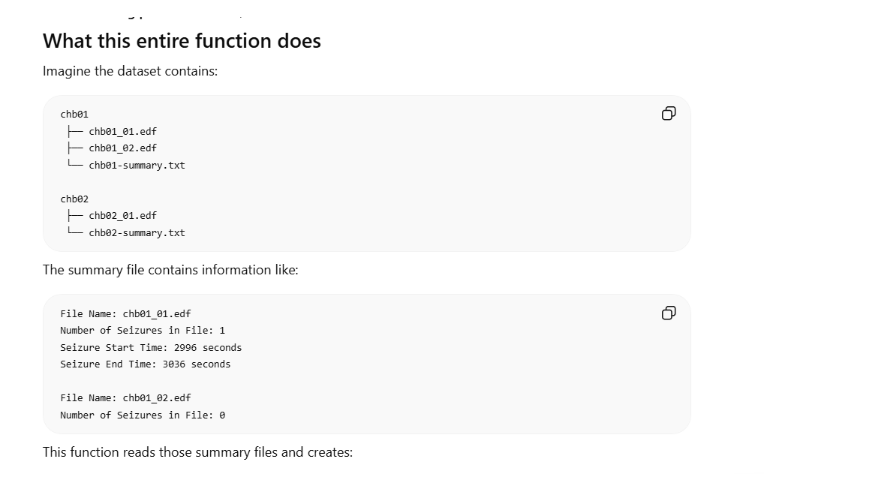

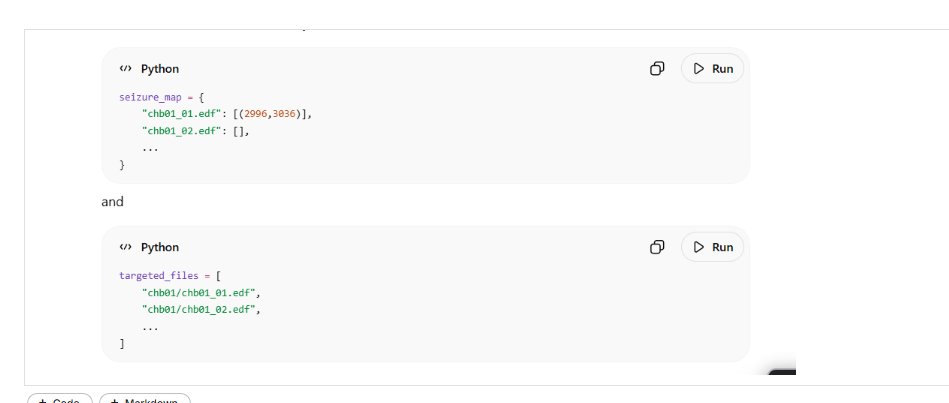

In [ ]:
# ==============================================================================
# PHASE 1: ALL-FILE REGEX SUMMARY PARSER
# ==============================================================================
print("\n🔎 PHASE 1: PARSING ALL EEG FILES...")
def parse_patient_summaries_comprehensive(patient_list):
    seizure_map = {}
    targeted_files = []

    for patient in patient_list:
        summary_filename = f"{patient}-summary.txt"
        local_summary_path = os.path.join(WORK_DIR,summary_filename)  
        #local_summary_path = "/kaggle/working/chb01-summary.txt"..where we want the summary file to exist on Kaggle.
        
        if not os.path.exists(local_summary_path):  #file not existing then we need to download 
            os.system(f"curl -L -s -o {local_summary_path} {BASE_URL}{patient}/{summary_filename}") 

        if not os.path.exists(local_summary_path):
            continue

                #Suppose download failed. Then: No summary file....So:continue means: Skip this patient and move to the next one.
        




            #now we have so far created local suammry path now we will go into that pah open zoom in extact the "chb01_01.edf" etc along with seizre star an dedn time  [(2996,3036)],


        with open(local_summary_path,'r') as f:
            content = f.read() #Read the entire summary file into one big string.
            file_blocks = content.split("File Name:") #seperating file name alone 
            for block in file_blocks[1:]: #Skip the empty first entry.
                lines = block.split("\n") #break each line seperately for each individual for a file bloack
                file_name = lines[0].strip() #curb out first line of that lines which is file ae with .edf eg file_name = "chb01_01.edf"
                if not file_name.endswith('.edf'): #just 4 saf8y purposes
                    continue
                num_seizures = 0
                for line in lines:
                    if "Number of Seizures" in line:
                        match = re.search(r'\d+', line) #Number of Seizures in File: 3->3
                        if match:
                            num_seizures = int(match.group()) #Convert text into integer
                        break
                      
                    
           
                intervals = []
                if num_seizures > 0:
                    for idx, line in enumerate(lines):
                        if "Seizure" in line and "Start Time" in line:
                            start_match = re.search(r'(\d+)\s*seconds', line)
                            end_line = lines[idx+1] if idx+1 < len(lines) else ""
                            end_match = re.search(r'(\d+)\s*seconds', end_line)
                            if start_match and end_match:
                                intervals.append((int(start_match.group(1)), int(end_match.group(1))))
                            
                seizure_map[file_name] = intervals
                targeted_files.append(f"{patient}/{file_name}")
            
    return targeted_files, seizure_map

train_files, train_seizures = parse_patient_summaries_comprehensive(TRAIN_PATIENTS)
val_files, val_seizures = parse_patient_summaries_comprehensive(VAL_PATIENTS)
test_files, test_seizures = parse_patient_summaries_comprehensive(TEST_PATIENTS)

GLOBAL_SEIZURE_MAP = {**train_seizures, **val_seizures, **test_seizures}

print(f"   Mapped {len(train_files)} files across Training subjects.")
print(f"   Mapped {len(val_files)} files across Validation subjects.")
print(f"   Mapped {len(test_files)} files across Testing subjects.")

                  
                      
            
            

            
            

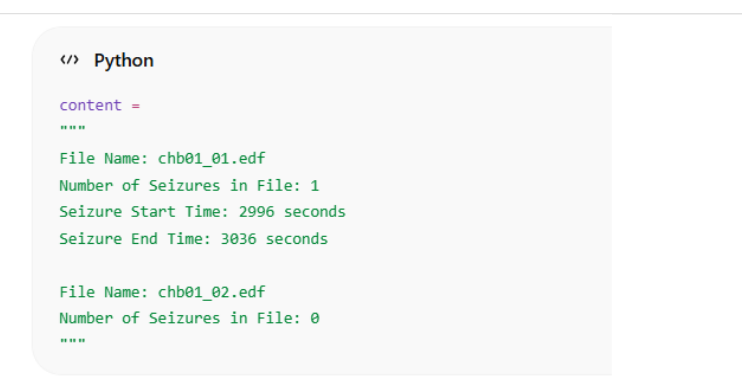

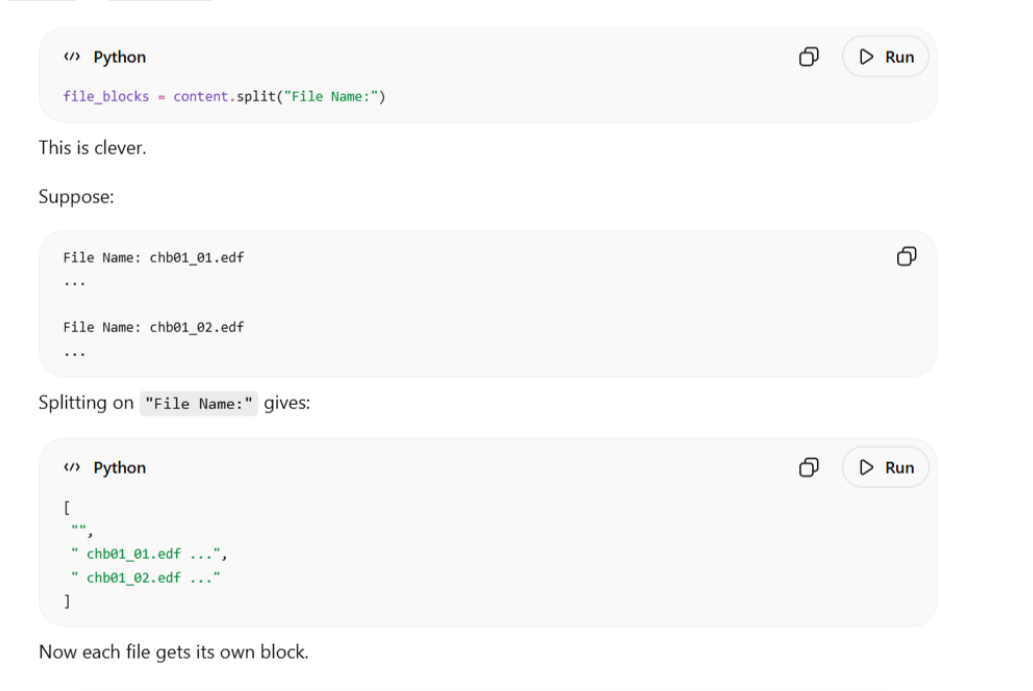

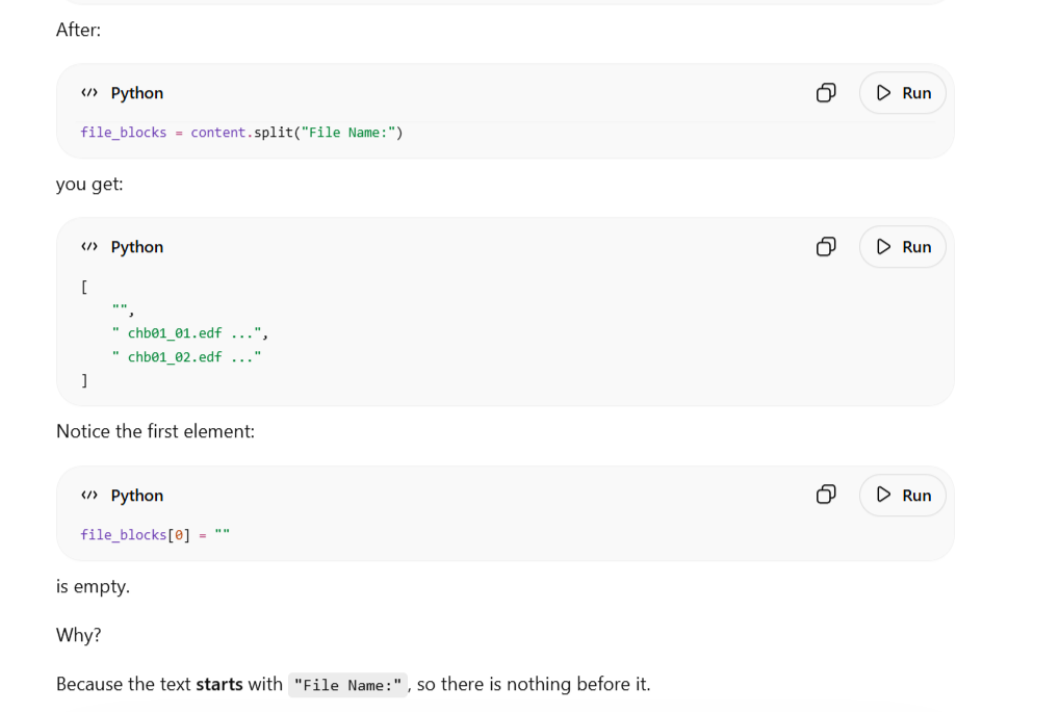

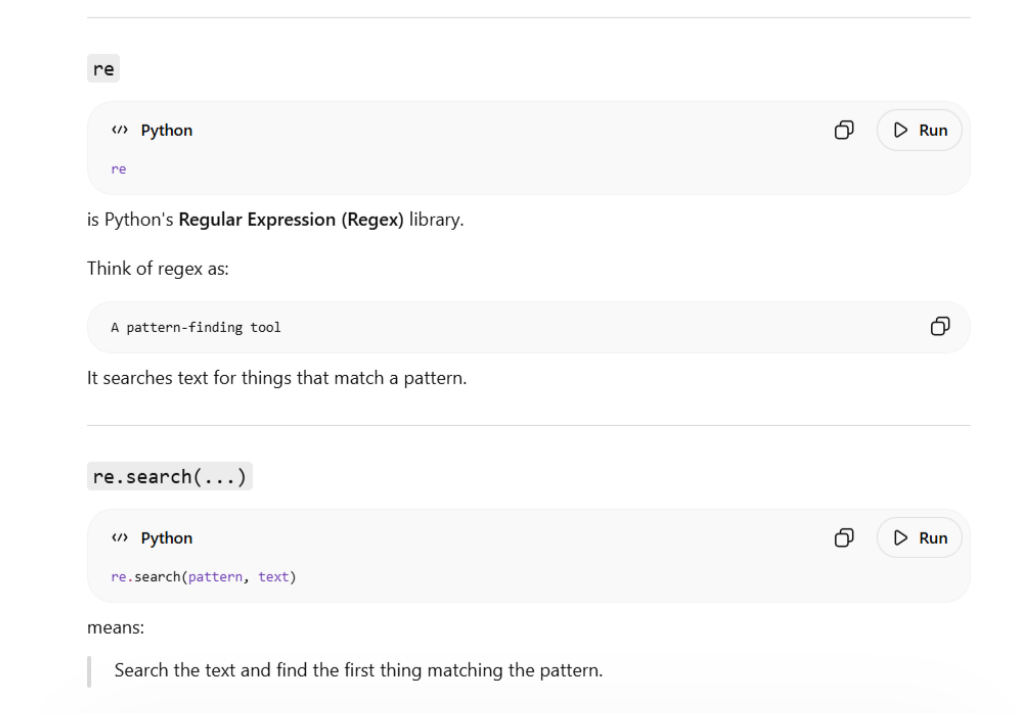

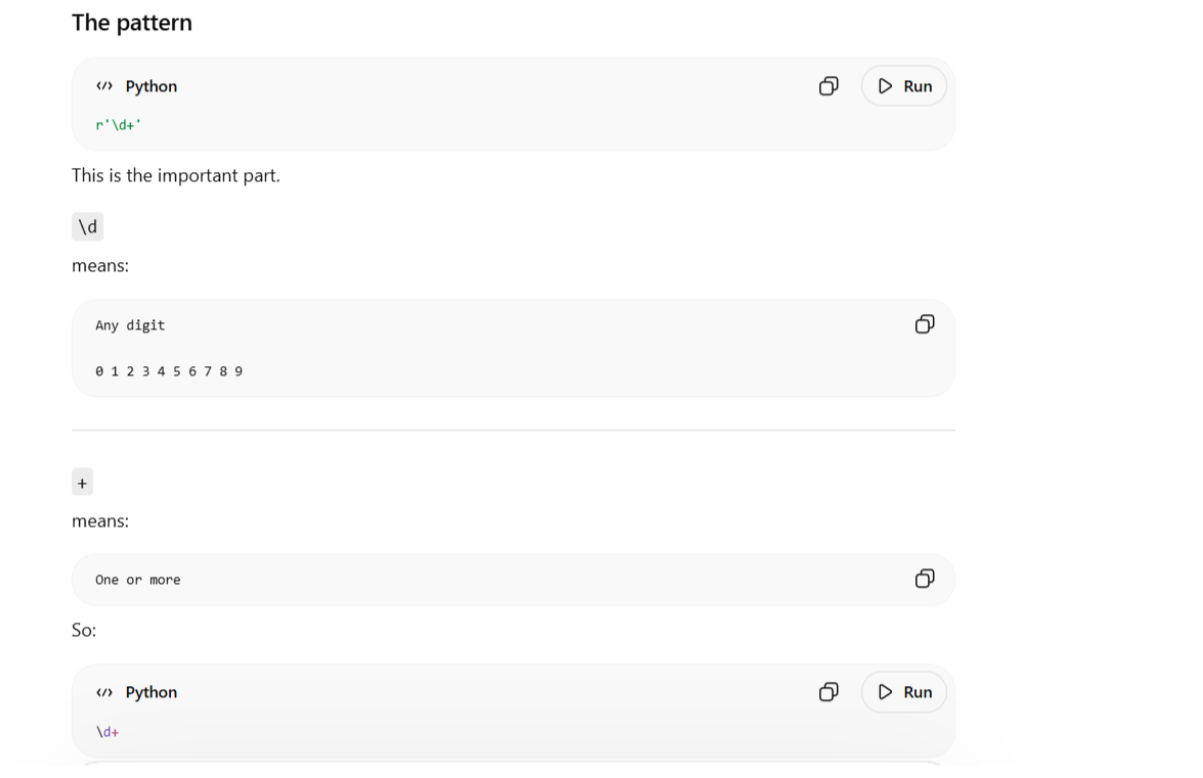

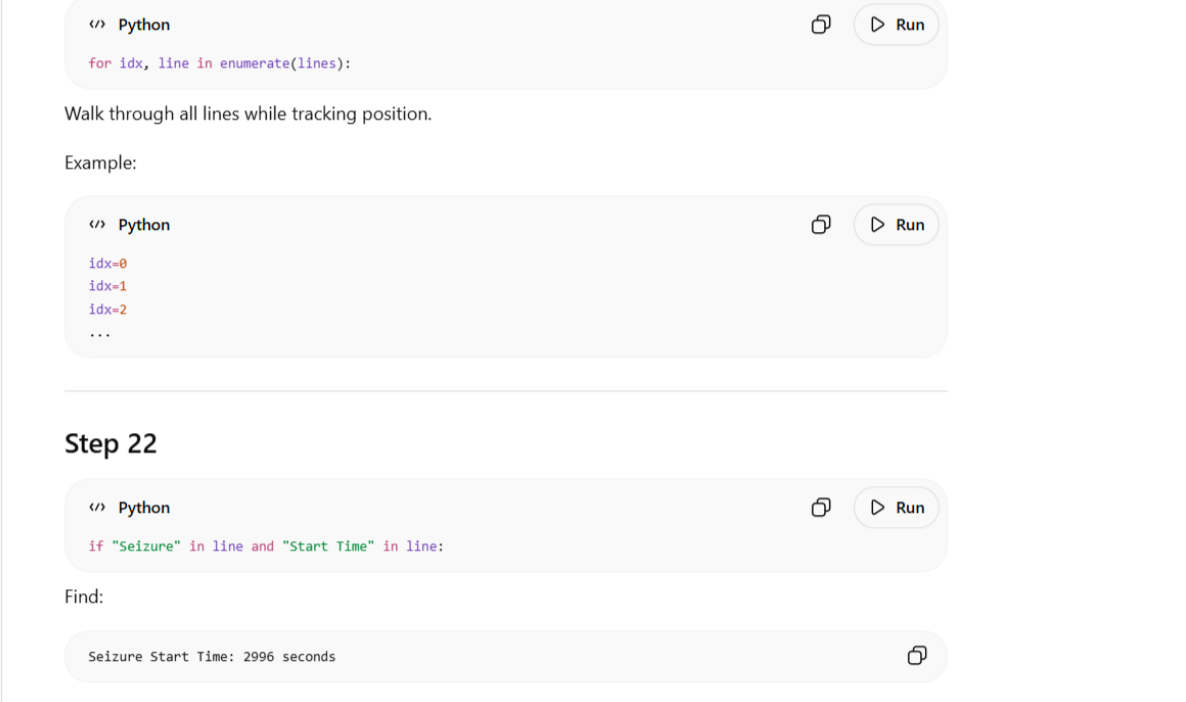

In [ ]:
# ==============================================================================
# PHASE 2: PARALLEL CHANNEL EXTRACTION & COMPREHENSIVE WINDOWING
# ==============================================================================
print("\n🚀 PHASE 2: EXTRACTING AND STANDARDIZING MULTI-CHANNEL WINDOW ARRAYS...")

def normalize_multi_channel_windows(X_raw):
    """
    Standardizes each channel inside each 4-second window independently
    to preserve spatial amplitude variance.
    """
    X_norm = np.zeros_like(X_raw, dtype=np.float32)
    for w_idx in range(X_raw.shape[0]):
        for ch_idx in range(X_raw.shape[2]):
            channel_slice = X_raw[w_idx, :, ch_idx]
            std_val = np.std(channel_slice)
            X_norm[w_idx, :, ch_idx] = (channel_slice - np.mean(channel_slice)) / (std_val + 1e-8)
    return X_norm


def download_and_extract_windows(file_list, max_files_per_cohort=25):
    X_list, y_list = [], []
    
    # Restrict cohort files to respect Kaggle's 16GB RAM constraints during data extraction
    selected_files = file_list[:max_files_per_cohort]
    
    for file_idx, remote_path in enumerate(selected_files, 1):
        print(f"   📁 [{file_idx}/{len(selected_files)}] Processing: {remote_path}")
        file_name = os.path.basename(remote_path)
        local_path = os.path.join(EDF_FOLDER, file_name)
        
        if not os.path.exists(local_path) or os.path.getsize(local_path) < 1000000:
            os.system(f"curl -L -s -o {local_path} {BASE_URL}{remote_path}")
            
        try:
            # Load raw data
            raw = mne.io.read_raw_edf(local_path, preload=True, verbose=False)
            
            # --- ROBUST CHANNEL CLEANUP ---
            drop_chans = []
            rename_dict = {}
            for ch in raw.ch_names:
                # Drop MNE's secondary duplicates or broken blank channels (like in chb17)
                if ch.endswith('-1') or ch.endswith('-2') or ch.strip() == '-':
                    drop_chans.append(ch)
                else:
                    # Remove 'EEG ' prefix and MNE's primary duplicate suffix '-0'
                    clean_name = ch.upper().replace('EEG ', '').replace('-0', '')
                    rename_dict[ch] = clean_name
                    
            if drop_chans:
                raw.drop_channels(drop_chans)
            raw.rename_channels(rename_dict)
            
            # Keep only the standardized channels present across these subjects
            existing_channels = [ch for ch in STANDARD_CHANNELS if ch in raw.ch_names]
            
            # If a file is genuinely missing a core channel, skip it to prevent shape crashes
            if len(existing_channels) != NUM_CHANNELS:
                print(f"      ⚠️ Skipping {file_name}: Missing core channels.")
                continue
                
            # Filter strictly to the 18 standard channels
            raw.pick_channels(existing_channels, ordered=True)
            # ------------------------------
            
            raw.resample(TARGET_FS, verbose=False)
            raw.filter(1., 30., verbose=False)
            
            # Extract and transpose from (Channels, TimeSteps) to (TimeSteps, Channels)
            data = raw.get_data() * 1e6  
            data = data.T 
            
            n_windows = len(data) // POINTS_PER_WINDOW 
            file_seizures = GLOBAL_SEIZURE_MAP.get(file_name, [])
            
            for i in range(n_windows):
                start = i * POINTS_PER_WINDOW
                end = start + POINTS_PER_WINDOW
                window_start_sec = start / TARGET_FS 
                window_end_sec = end / TARGET_FS
                
                is_seizure = 0
                for (s_start, s_end) in file_seizures:
                    if window_start_sec < s_end and window_end_sec > s_start:
                        is_seizure = 1
                        break
                
                # RAM Mitigation: 5% background random sampling
                if is_seizure == 1 or random.random() < 0.05:
                    window_data = data[start:end, :]
                    if window_data.shape[0] == POINTS_PER_WINDOW and window_data.shape[1] == NUM_CHANNELS:
                        X_list.append(window_data)
                        y_list.append(is_seizure)
                        
            del raw
            if os.path.exists(local_path):
                os.remove(local_path)
                
        except Exception as e:
            print(f"      ⚠️ Error processing file {file_name}: {e}")
            
    return np.array(X_list), np.array(y_list)



# --- NEW PRIORITIZATION BLOCK ---
# --- CORRECTED PRIORITIZATION BLOCK ---
# Sort files so that EDFs containing >0 seizures are downloaded first
def prioritize_seizure_files(file_list):
    return sorted(
        file_list, 
        key=lambda filepath: 0 if len(GLOBAL_SEIZURE_MAP.get(os.path.basename(filepath), [])) > 0 else 1
    )

train_files = prioritize_seizure_files(train_files)
val_files = prioritize_seizure_files(val_files)
test_files = prioritize_seizure_files(test_files)
# --------------------------------------



print("   Building Parallel Training Matrix...")
X_train_raw, y_train = download_and_extract_windows(train_files, max_files_per_cohort=30)
print("   Building Parallel Validation Matrix...")
X_val_raw, y_val = download_and_extract_windows(val_files, max_files_per_cohort=10)
print("   Building Parallel Testing Matrix...")
X_test_raw, y_test = download_and_extract_windows(test_files, max_files_per_cohort=10)

# Apply independent per-window, per-channel Z-score scaling
X_train = normalize_multi_channel_windows(X_train_raw)
X_val = normalize_multi_channel_windows(X_val_raw)
X_test = normalize_multi_channel_windows(X_test_raw)

# --- DIAGNOSTIC DATASET CHECK BLOCK ---
print("\n📊 DATASET CHECK")
print("Train seizure windows :", np.sum(y_train == 1))
print("Train normal windows  :", np.sum(y_train == 0))
print("Val seizure windows   :", np.sum(y_val == 1))
print("Val normal windows    :", np.sum(y_val == 0))
print("Test seizure windows  :", np.sum(y_test == 1))
print("Test normal windows   :", np.sum(y_test == 0))
print(f"Input Matrix Shapes   : {X_train.shape} -> (Samples, TimeSteps, Parallel Features)")
print("========================================\n")

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

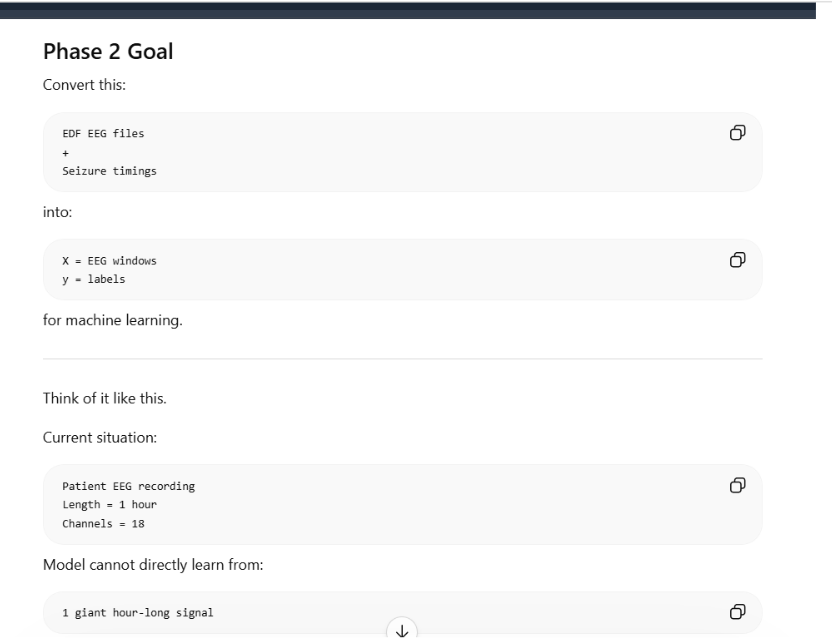

In [ ]:

# Result:
#
#     X = [window1, window2, window3, ...]
#     y = [0, 0, 1, ...]
#
# This is the format required by machine learning models.
#
# ------------------------------------------------------------------------------
# WHAT DOES MULTI-CHANNEL MEAN?
# ------------------------------------------------------------------------------
#
# We selected 18 standard EEG channels.
#
# One 4-second window after resampling contains:
#
#     Channel 1  → 256 values
#     Channel 2  → 256 values
#     ...
#     Channel18  → 256 values
#
# Window shape:
#
#     (256, 18)
#
# Meaning:
#
#     256 time samples
#     18 EEG channels
#
# Visualization:
#
#     Time →
#
#     FP1-F7    x x x x x x
#     F7-T7     x x x x x x
#     T7-P7     x x x x x x
#     ...
#     CZ-PZ     x x x x x x
#
# Rows = channels
# Columns = time points
#
# ------------------------------------------------------------------------------
# WHY NORMALIZE?
# ------------------------------------------------------------------------------
#
# Different EEG channels can have very different amplitudes.
#
# Example:
#
#     Channel A:
#         -300 to +300
#
#     Channel B:
#         -20 to +20
#
# Larger values may dominate training.
#
# Therefore each channel is standardized independently:
#
#     Mean ≈ 0
#     Std  ≈ 1
#
# This makes learning more stable.
#
# ------------------------------------------------------------------------------
# WHY FILTER BETWEEN 1-30 Hz?
# ------------------------------------------------------------------------------
#
# Raw EEG often contains:
#
#     • Slow baseline drift
#     • Electrical interference
#     • Recording artifacts
#
# Many seizure-related EEG patterns are found roughly within:
#
#     1 Hz to 30 Hz
#
# Therefore:
#
#     Keep useful EEG information
#     Remove unnecessary noise
#
# ------------------------------------------------------------------------------
# WHY RESAMPLE FROM 256 Hz TO 64 Hz?
# ------------------------------------------------------------------------------
#
# Original:
#
#     1 second = 256 samples
#
# After resampling:
#
#     1 second = 64 samples
#
# For a 4-second window:
#
# Original:
#
#     4 × 256 = 1024 samples/channel
#
# Resampled:
#
#     4 × 64 = 256 samples/channel
#
# Benefits:
#
#     • Smaller dataset
#     • Faster training
#     • Lower memory usage
#
# ------------------------------------------------------------------------------
# WHY KEEP ONLY 5% OF NORMAL WINDOWS?
# ------------------------------------------------------------------------------
#
# Code:
#
#     if is_seizure == 1 or random.random() < 0.05:
#
# EEG datasets are highly imbalanced.
#
# Example:
#
#     Normal windows  = 100,000
#     Seizure windows = 500
#
# Training on such data can cause the model to predict only "normal".
#
# Strategy:
#
#     Keep ALL seizure windows
#     Keep only 5% of normal windows
#
# Example:
#
#     100,000 normal
#         ↓
#      5,000 normal
#
#        500 seizure
#         ↓
#        500 seizure
#
# Produces a much healthier class balance.
#
# ------------------------------------------------------------------------------
# FINAL OUTPUT OF PHASE 2
# ------------------------------------------------------------------------------
#
# Before Phase 2:
#
#     EDF recordings
#     +
#     Seizure timestamps
#
# After Phase 2:
#
#     X_train
#     y_train
#
#     X_val
#     y_val
#
#     X_test
#     y_test
#
# Each sample shape:
#
#     (256, 18)
#
# Meaning:
#
#     4 seconds duration
#     64 Hz sampling rate
#     18 EEG channels
#
# Label:
#
#     0 = Normal
#     1 = Seizure
#
# ------------------------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------------------------
#
# Phase 2 converts raw EEG recordings into clean, filtered,
# standardized, labeled 4-second multi-channel windows that can be
# directly fed into a Bi-LSTM for seizure detection.
#
# ------------------------------------------------------------------------------

In [ ]:
# ==============================================================================
# PHASE 3: PARALLEL INPUT BI-LSTM ARCHITECTURE
# ==============================================================================
print("🧠 PHASE 3: MOUNTING PARALLEL MULTI-CHANNEL BI-LSTM NET...")

model = Sequential([
    # Input now dynamically tracks all standardized parallel channels
    Input(shape=(POINTS_PER_WINDOW, NUM_CHANNELS)),  #256,18
    Bidirectional(LSTM(64)), #sice bi 64 features 4 2wd lstm 64 4 backward lstm
    Dropout(0.3), #Randomly ignore 30% neurons during training
    Dense(32, activation='relu'), #fully connecte dlayer from 128 input fetures it outputs 32 features
    Dense(1, activation='sigmoid') #output layer
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

print("🚀 Starting scalable GPU model fitting loop...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)





In [ ]:
# ==============================================================================
# PHASE 4 & 5: CLINICAL THRESHOLD TUNING RUNTIME (STANDARD BI-LSTM)
# ==============================================================================
print("\n📈 PHASE 4 & 5: EXTRACTING TEST GENERATION INSIGHTS...")

# Get raw probabilities from the unseen test set
preds_prob_test = model.predict(X_test, verbose=0)

# We will test thresholds from 0.1 to 0.5 to find the clinical sweet spot
thresholds_to_test = [0.10, 0.15, 0.20, 0.30, 0.40, 0.50]

print("\n📊 MULTI-CHANNEL BI-LSTM: THRESHOLD SWEEP (UNSEEN SUBJECTS)")
print(f"Total Test Windows: {len(y_test)} (Seizure: {np.sum(y_test == 1)} | Normal: {np.sum(y_test == 0)})\n")
print(f"{'Threshold':<10} | {'Recall (Sens)':<15} | {'Specificity':<15} | {'F1-Score':<10} | {'G-Mean':<10}")
print("-" * 70)

best_threshold = 0.5
best_gmean = 0

for thresh in thresholds_to_test:
    # Apply the current custom threshold
    preds_test = (preds_prob_test > thresh).astype(int).flatten()
    
    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(y_test, preds_test).ravel()
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    
    # Handle cases where precision + recall might be 0 to avoid warnings
    f1 = f1_score(y_test, preds_test, zero_division=0)
    g_mean = geometric_mean_score(y_test, preds_test)
    
    print(f"{thresh:<10.2f} | {sensitivity:<15.4f} | {specificity:<15.4f} | {f1:<10.4f} | {g_mean:<10.4f}")
    
    if g_mean > best_gmean:
        best_gmean = g_mean
        best_threshold = thresh

print("\n" + "="*70)
print(f"🏆 BEST CLINICAL THRESHOLD: {best_threshold} (Based on G-Mean)")
print(f"ROC-AUC Metric: {roc_auc_score(y_test, preds_prob_test):.4f}")

# Print the final detailed classification report for the best threshold
final_preds = (preds_prob_test > best_threshold).astype(int).flatten()
print(f"\n📄 DETAILED REPORT AT THRESHOLD {best_threshold}:")
print(classification_report(y_test, final_preds, target_names=['Healthy', 'Seizure'], zero_division=0))

# Generate the final confusion matrix using the best discovered threshold
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Healthy', 'Seizure'], yticklabels=['Healthy', 'Seizure'])
plt.title(f'Unseen Test Cohort: Standard Bi-LSTM @ Threshold {best_threshold}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Excellent question. Now you're thinking like someone implementing the model, not just studying the diagram.

# Let's walk through exactly what happens when you give a new unseen EEG window to a trained LSTM seizure detector.

# During Inference (Testing)

# Suppose you have a trained model:

# LSTM(32) Dense(32, relu) Dense(1, sigmoid)

# and a new EEG window:

# X = [x₁, x₂, x₃, ... , x₅₀₀]

# Step 1: Initialize Memory

# Before reading the EEG:

# h₀ = 0 C₀ = 0

# or very close to zero.

# Important:

# 👉 The model does NOT reuse memory from the previous patient's EEG.

# Every new EEG window starts fresh.

# New EEG Window ↓ h₀ = 0 C₀ = 0

# Step 2: First EEG Point Arrives

# Suppose:

# x₁ = 0.7

# The LSTM computes:

# Forget Gate

# Should I keep old memory?

# But:

# C₀ = 0

# so nothing much happens.

# Input Gate

# Should I store information from x₁ ?

# Maybe:

# Store 60%

# Cell State Update

# Now:

# C₁

# contains some information from x₁.

# Output Gate

# The LSTM decides:

# What part of C₁ should become visible?

# and creates:

# h₁

# Result:

# x₁ ↓ (C₁,h₁)

# Step 3: Second EEG Point Arrives

# Now:

# x₂

# comes in.

# The LSTM receives:

# x₂ h₁ C₁

# Notice:

# RNN only had h₁

# LSTM has: h₁ + C₁

# Two memories.

# The gates now ask:

# Forget Gate

# How much of C₁ should I keep?

# Maybe:

# Keep 95%

# Input Gate

# Is x₂ important?

# Maybe:

# Add some of x₂

# Cell State Update

# C₂

# becomes:

# Old Memory + Useful part of x₂

# Output Gate

# Creates:

# h₂

# from:

# C₂

# Repeat 500 Times

# The LSTM processes:

# x₁ x₂ x₃ ... x₅₀₀

# and continuously updates:

# C₁ → C₂ → C₃ → ... → C₅₀₀

# h₁ → h₂ → h₃ → ... → h₅₀₀

# What Does C Learn?

# Imagine the EEG contains seizure patterns around:

# Time 150

# The Input Gate may decide:

# IMPORTANT! Store this.

# So the Cell State starts carrying:

# Possible seizure evidence

# through many future time steps.

# Final Step

# After:

# x₅₀₀

# the LSTM has:

# Final Cell State: C₅₀₀

# Final Hidden State: h₅₀₀

# The classifier typically receives:

# h₅₀₀

# not C₅₀₀.

# h₅₀₀ ↓ Dense(32) ↓ Dense(1) ↓ Sigmoid

# What Is h₅₀₀ Actually?

# Think of it as:

# A learned summary of the entire EEG window

# Maybe internally:

# h₅₀₀ = [ seizure_spike_feature, rhythm_feature, frequency_feature, morphology_feature, ... ]

# Not literally these names, but learned numerical features.

# Feed Forward Network

# Dense layer receives:

# h₅₀₀

# and learns rules like:

# If feature 3 is high AND feature 7 is high → seizure

# Eventually:

# Dense(1, sigmoid)

# outputs:

# 0.93

# meaning:

# 93% seizure probability

# or

# 0.04

# meaning:

# 4% seizure probability

# Entire Pipeline

# New EEG Window ↓ Initialize: h₀ = 0 C₀ = 0

#    ↓
# x₁ ↓ Forget Gate Input Gate Output Gate ↓ (C₁,h₁)

#    ↓
# x₂ ↓ Forget Gate Input Gate Output Gate ↓ (C₂,h₂)

#    ↓
# ... ↓

# x₅₀₀ ↓ (C₅₀₀,h₅₀₀)

#    ↓
# Dense Layer

#    ↓
# Sigmoid

#    ↓
# P(Seizure)

# The key insight is:

# Cell State (C) = long-term storage

# Hidden State (h) = filtered summary exposed to the outside world

# Dense layers classify using h

# So during inference, the gates are still actively working at every EEG sample, deciding what information enters the memory, what information stays in memory, and what information is exposed through the hidden state to eventually make the seizure/non-seizure decision.

# add Codeadd Markdown
# AHA! 🔥

# You've found the missing piece.

# You're asking:

# "During testing, I see x₁→x₂→...→x₅₀₀, gates, h, C, Dense, Sigmoid.

# But where is all the training data? Where are all those labeled seizure/non-seizure EEGs being used?"

# Excellent question.

# The answer is:

# The training EEGs are NOT used during testing. What remains from training is the learned weights.

# Think of a Student

# During training:

# 1000 EEG windows + their labels

# The LSTM studies them.

# EEG #1 → Seizure EEG #2 → Non-seizure EEG #3 → Seizure ...

# Over time it learns:

# Which patterns usually mean seizure Which patterns usually mean non-seizure

# What Actually Gets Learned?

# The weights.

# For example:

# Forget Gate weights

# Input Gate weights

# Output Gate weights

# Dense layer weights

# All these numbers are updated during training.

# Imagine Before Training

# Forget Gate weight:

# 0.12

# Input Gate weight:

# -0.48

# Dense weight:

# 0.05

# Random garbage.

# After seeing thousands of EEGs:

# Forget Gate weight: 2.31

# Input Gate weight: -1.72

# Dense weight: 4.88

# Now these weights contain knowledge.

# Where Is The Training Data During Testing?

# It isn't.

# Only the learned weights remain.

# Think:

# Training Data ↓ Learning ↓ Weights Updated ↓ Training Data Discarded ↓ Keep Learned Weights

# Doctor Analogy

# A doctor studies:

# 10,000 EEG recordings

# during medical school.

# Years later a patient arrives.

# Does the doctor go back and reread all 10,000 EEGs?

# No.

# The knowledge is already stored in his brain.

# Similarly:

# Training EEGs

# are the "school."

# The trained weights are the "brain."

# What Happens During Testing?

# New EEG:

# x₁ → x₂ → ... → x₅₀₀

# passes through:

# Already-trained gates Already-trained LSTM Already-trained Dense layers

# using the weights learned earlier.

# Example

# Suppose during training the model discovered:

# Rapid rhythmic spikes + Specific frequency changes
# Often seizure

# This knowledge becomes encoded inside weights.

# Then a new EEG arrives:

# Unseen EEG

# The gates automatically react because of those learned weights.

# For example:

# Input Gate: "Store this spike pattern."

# Forget Gate: "This looks important, don't forget it."

# Why?

# Because training adjusted the gate weights to behave that way.

# The Real Role of Training

# Training is not memorizing EEGs.

# Training is:

# Finding good weights

# that make:

# Seizure EEGs → output near 1

# Non-seizure EEGs → output near 0

# A More Accurate Picture

# Training

# EEG Window ↓ LSTM ↓ Prediction

# Compare with Label ↓ Compute Error ↓ Backpropagation ↓ Update Weights

# Repeat thousands of times.

# Testing

# EEG Window ↓ LSTM (using frozen learned weights) ↓ Prediction

# No weight updates.

# No labels.

# No training EEGs.

# Just forward propagation.

# This is actually the perfect moment to learn Backpropagation Through Time (BPTT), because that's the mechanism that takes the seizure/non-seizure error and modifies the Forget Gate, Input Gate, Output Gate, and Dense weights during training. That's the bridge between "labeled EEGs" and "a trained LSTM that can classify new EEGs." 🔥

# add Codeadd Markdown
# This is one of the deepest questions in machine learning. 🔥

# You're asking:

# "If the weights are frozen during testing, and every EEG is different, how can the SAME weights work for all EEGs?"

# The answer is:

# The weights are not memorizing EEG signals. They are learning general patterns.

# Imagine Learning Cats

# Suppose during training you see:

# Cat 1 Cat 2 Cat 3 ... Cat 10000

# Every cat looks different.

# Yet after training, you can identify a new cat you've never seen.

# Why?

# Because your brain didn't memorize every cat.

# It learned:

# Whiskers Pointed ears Cat-like face shape

# These are patterns.

# Same for EEG

# During training the LSTM sees:

# Seizure EEG #1 Seizure EEG #2 Seizure EEG #3 ...

# All different.

# But many share characteristics:

# Sudden spikes Rhythmic bursts Frequency changes Amplitude changes

# The weights learn to detect these characteristics.

# Think of Weights as Detectors

# Suppose one neuron learns:

# "Look for rapid spike sequences"

# Another learns:

# "Look for rhythmic oscillations"

# Another learns:

# "Look for abnormal amplitude changes"

# These detectors work on ANY EEG.

# New EEG Arrives

# Suppose training never saw:

# Patient XYZ

# before.

# The LSTM processes:

# New EEG ↓ Same learned weights

# and asks:

# Do I see spike patterns? Do I see rhythmic bursts? Do I see seizure-like signatures?

# The weights are reused because those learned features are general.

# Analogy: English Reading

# You learned English using millions of sentences.

# Today you can read:

# A sentence you've never seen before.

# How?

# Because your brain learned:

# Grammar rules Word meanings Sentence structure

# not individual sentences.

# What If Weights Had To Change Every Test EEG?

# That would be impossible.

# Suppose a hospital receives:

# Patient A Patient B Patient C Patient D

# You can't retrain the model every time.

# Instead:

# Training ↓ Learn general rules ↓ Freeze weights ↓ Apply rules to new EEGs

# Then Why Doesn't It Get 100% Accuracy?

# Because the learned rules are not perfect.

# Sometimes a new EEG may contain:

# Rare seizure pattern Unusual noise Artifacts Patient-specific variations

# that weren't well represented in training.

# Then the model may misclassify.

# That's why we evaluate:

# Accuracy F1-score Sensitivity Specificity

# on unseen test data.

# The Key Mental Shift

# Don't think:

# Weights = Memory of EEGs

# Think:

# Weights = Rules learned from EEGs

# During testing:

# New EEG ↓ Fresh h₀ and C₀ ↓ Processed using learned rules (weights) ↓ New h₁, h₂, ... h₅₀₀ New C₁, C₂, ... C₅₀₀ ↓ Prediction

# So:

# Weights stay fixed (the learned knowledge).

# Hidden state h and Cell state C are rebuilt from scratch for every new EEG window.

# That's the crucial distinction:

# Weights = Permanent learned knowledge

# h and C = Temporary memory for the current EEG being analyzed

# Once you see it this way, the entire training/testing process becomes much more intuitive. 🎯

# add Codeadd Markdown
# Perfect. You now understand:

# RNN
#   ↓
# LSTM
# So Bi-LSTM becomes very easy.

# First: Why LSTM May Miss Information
# Suppose your EEG window is:

# x1  x2  x3  x4  x5  ... x500
# A normal LSTM reads:

# x1 → x2 → x3 → ... → x500
# only forward.

# At time 100 it only knows:

# x1 ... x100
# It does NOT know:

# x101 ... x500
# yet.

# EEG Example
# Suppose:

# Time 100
# contains a suspicious spike.

# To decide whether it's seizure-related, it might help to know what happens after:

# Time 101-200
# But a forward LSTM hasn't seen that future yet.

# Bi-LSTM's Idea
# Researchers said:

# Why not read the sequence from BOTH directions?

# So Bi-LSTM creates TWO LSTMs.

# Forward LSTM
# Reads:

# x1 → x2 → x3 → ... → x500
# Produces:

# hf
# (forward hidden state)

# Backward LSTM
# Reads:

# x500 → x499 → x498 → ... → x1
# Produces:

# hb
# (backward hidden state)

# Visual:

# Forward:

# x1 → x2 → x3 → x4 → x5

# Backward:

# x1 ← x2 ← x3 ← x4 ← x5
# Both happen simultaneously.

# What Does Each Learn?
# Forward LSTM:

# Uses past information
# Example:

# Spike at time 50
# affects time 100
# Backward LSTM:

# Uses future information
# Example:

# Pattern at time 150
# helps interpret spike at time 100
# Combining Them
# Suppose:

# Forward LSTM gives:

# hf = [1,2,3]
# Backward LSTM gives:

# hb = [4,5,6]
# Bi-LSTM combines them:

# [1,2,3,4,5,6]
# This is called concatenation.

# In Your Code
# You have:

# Bidirectional(
#     LSTM(64, return_sequences=True)
# )
# This means:

# Forward LSTM:
# 64 features

# Backward LSTM:
# 64 features
# Combined:

# 128 features
# for every time step.

# Then Your Second LSTM
# Your architecture:

# Bidirectional(LSTM(64, return_sequences=True))

# LSTM(32)
# becomes:

# EEG
#  ↓

# Bi-LSTM
#  ↓

# Sequence of richer features
#  ↓

# LSTM(32)
#  ↓

# Final summary
#  ↓

# Dense
#  ↓

# Sigmoid
# Why Bi-LSTM Is Good For EEG
# Suppose seizure pattern exists between:

# Time 200 and Time 300
# A point at:

# Time 250
# can be understood using:

# Past
# Time 200-249
# and

# Future
# Time 251-300
# Bi-LSTM sees both.

# During Training
# Bi-LSTM learns:

# Forward weights

# Forward forget gate weights
# Forward input gate weights
# Forward output gate weights
# AND

# Backward weights

# Backward forget gate weights
# Backward input gate weights
# Backward output gate weights
# So it has roughly twice the learning capacity.

# During Testing on a New EEG
# Suppose:

# New EEG Window
# arrives.

# The model initializes:

# Forward:
# hf0 = 0
# Cf0 = 0

# Backward:
# hb0 = 0
# Cb0 = 0
# Then:

# Forward LSTM
# x1 → x2 → ... → x500
# builds:

# hf
# Backward LSTM
# x500 → ... → x2 → x1
# builds:

# hb
# Combine
# [hf , hb]
# Feed to Next Layers
# [hf , hb]
#       ↓
# LSTM(32)
#       ↓
# Dense(32)
#       ↓
# Sigmoid
#       ↓
# Seizure Probability
# Mental Picture
# RNN
# Past only
# LSTM
# Past only
# +
# Better memory
# Bi-LSTM
# Past
# +
# Future
# +
# Better memory
# For your seizure detection project, the biggest advantage of Bi-LSTM is that a seizure pattern is often spread across a time window. A Bi-LSTM can analyze each EEG point using both what happened before it and what happens after it, giving a richer representation before the final classifier decides seizure vs non-seizure. 🎯

# add Codeadd Markdown


<!-- Perfect. This is the most important part of your current model.

You already know your input shape is:

```text
(256,18)
```

Meaning:

```text
256 timesteps
18 EEG channels
```

Let's understand exactly what the Bi-LSTM sees.

---

# Step 1: One EEG Window

Suppose we zoom into just 3 timesteps and 4 channels.

Real data is:

```text
(256,18)
```

but let's shrink it:

| Time | Ch1 | Ch2  | Ch3 | Ch4 |
| ---- | --- | ---- | --- | --- |
| t1   | 0.5 | -0.2 | 1.0 | 0.3 |
| t2   | 0.7 | -0.1 | 0.8 | 0.4 |
| t3   | 0.9 | 0.0  | 0.7 | 0.5 |

This is one EEG window.

---

# Step 2: What arrives at the LSTM?

At timestep 1:

```text
x₁ =
[0.5,-0.2,1.0,0.3]
```

In your real model:

```text
x₁ =
18 numbers
```

One number from each EEG channel.

---

Think:

```text
Time = row

Channels = columns
```

So every timestep contains:

```text
18 EEG measurements
```

simultaneously.

---

# Step 3: LSTM Input Dimension

Your model:

```python
Input(shape=(256,18))
```

means:

```text
Input Size = 18
```

So the LSTM receives:

```text
18 features
```

at every timestep.

---

Visual:

```text
t1 → 18 values
t2 → 18 values
t3 → 18 values
...
t256 → 18 values
```

---

# Step 4: What does LSTM do?

The LSTM walks through time.

```text
t1
↓
t2
↓
t3
↓
...
↓
t256
```

At each timestep it asks:

> "Given what I've already seen, should I remember this?"

---

Example

Suppose seizure activity begins around:

```text
t = 120
```

The LSTM may store:

```text
Interesting pattern detected
```

inside its memory.

Then at:

```text
t=121
t=122
t=123
```

it keeps updating that memory.

---

# Step 5: Why 64 LSTM Units?

Your code:

```python
Bidirectional(
    LSTM(64)
)
```

means:

```text
64 memory cells
```

Think of:

```text
64 tiny experts
```

inside the LSTM.

---

Expert 1:

```text
Looks for spikes
```

Expert 2:

```text
Looks for rhythmic oscillations
```

Expert 3:

```text
Looks for temporal slowing
```

etc.

---

So after processing:

```text
256 timesteps
```

the LSTM produces:

```text
64 features
```

from the forward direction.

---

# Step 6: Why Bidirectional?

Normal LSTM:

```text
t1 → t256
```

only.

---

Bi-LSTM:

Forward:

```text
t1 → t256
```

Backward:

```text
t256 → t1
```

simultaneously.

---

Visual:

```text
Forward LSTM
→→→→→→→→→

Backward LSTM
←←←←←←←←←
```

---

For EEG this is useful because:

A seizure pattern may be easier to identify when looking at:

```text
past
+
future
```

inside the 4-second window.

---

# Step 7: Output Dimension

Forward LSTM:

```text
64 outputs
```

Backward LSTM:

```text
64 outputs
```

Combined:

```text
64 + 64 = 128
```

So Bi-LSTM outputs:

```text
128 features
```

---

Shape becomes:

```text
(128,)
```

for each EEG window.

---

# Step 8: Dropout

```python
Dropout(0.3)
```

Means:

```text
30% neurons ignored
```

during training.

---

Why?

To reduce:

```text
Overfitting
```

which we actually observed:

```text
Best epoch = 3
```

and later training performance kept improving while validation worsened.

---

# Step 9: Dense(32)

```python
Dense(32)
```

takes:

```text
128 features
```

and compresses them into:

```text
32 features
```

---

Think:

```text
128 observations
↓
32 important summaries
```

---

# Step 10: Final Output

```python
Dense(1,activation='sigmoid')
```

produces:

```text
0.00 → non-seizure

1.00 → seizure
```

Examples:

```text
0.05
```

Very likely normal.

---

```text
0.40
```

Probably normal.

---

```text
0.92
```

Strong seizure evidence.

---

# Entire Flow

For ONE EEG window:

```text
(256,18)

256 timesteps
18 channels
        ↓

Bi-LSTM(64)

Learns temporal EEG patterns
        ↓

128 features

(64 forward + 64 backward)
        ↓

Dropout
        ↓

Dense(32)
        ↓

Dense(1)
        ↓

Seizure Probability
```

---

Now the interesting part for your next model (**Bi-LSTM + Attention**) is:

After the Bi-LSTM processes all 256 timesteps, **how does Attention decide which moments in those 256 timesteps are the most important?**

That is exactly where Attention starts helping seizure detection.
 -->

<!-- Perfect. This is the most important part of your current model.

You already know your input shape is:

```text
(256,18)
```

Meaning:

```text
256 timesteps
18 EEG channels
```

Let's understand exactly what the Bi-LSTM sees.

---

# Step 1: One EEG Window

Suppose we zoom into just 3 timesteps and 4 channels.

Real data is:

```text
(256,18)
```

but let's shrink it:

| Time | Ch1 | Ch2  | Ch3 | Ch4 |
| ---- | --- | ---- | --- | --- |
| t1   | 0.5 | -0.2 | 1.0 | 0.3 |
| t2   | 0.7 | -0.1 | 0.8 | 0.4 |
| t3   | 0.9 | 0.0  | 0.7 | 0.5 |

This is one EEG window.

---

# Step 2: What arrives at the LSTM?

At timestep 1:

```text
x₁ =
[0.5,-0.2,1.0,0.3]
```

In your real model:

```text
x₁ =
18 numbers
```

One number from each EEG channel.

---

Think:

```text
Time = row

Channels = columns
```

So every timestep contains:

```text
18 EEG measurements
```

simultaneously.

---

# Step 3: LSTM Input Dimension

Your model:

```python
Input(shape=(256,18))
```

means:

```text
Input Size = 18
```

So the LSTM receives:

```text
18 features
```

at every timestep.

---

Visual:

```text
t1 → 18 values
t2 → 18 values
t3 → 18 values
...
t256 → 18 values
```

---

# Step 4: What does LSTM do?

The LSTM walks through time.

```text
t1
↓
t2
↓
t3
↓
...
↓
t256
```

At each timestep it asks:

> "Given what I've already seen, should I remember this?"

---

Example

Suppose seizure activity begins around:

```text
t = 120
```

The LSTM may store:

```text
Interesting pattern detected
```

inside its memory.

Then at:

```text
t=121
t=122
t=123
```

it keeps updating that memory.

---

# Step 5: Why 64 LSTM Units?

Your code:

```python
Bidirectional(
    LSTM(64)
)
```

means:

```text
64 memory cells
```

Think of:

```text
64 tiny experts
```

inside the LSTM.

---

Expert 1:

```text
Looks for spikes
```

Expert 2:

```text
Looks for rhythmic oscillations
```

Expert 3:

```text
Looks for temporal slowing
```

etc.

---

So after processing:

```text
256 timesteps
```

the LSTM produces:

```text
64 features
```

from the forward direction.

---

# Step 6: Why Bidirectional?

Normal LSTM:

```text
t1 → t256
```

only.

---

Bi-LSTM:

Forward:

```text
t1 → t256
```

Backward:

```text
t256 → t1
```

simultaneously.

---

Visual:

```text
Forward LSTM
→→→→→→→→→

Backward LSTM
←←←←←←←←←
```

---

For EEG this is useful because:

A seizure pattern may be easier to identify when looking at:

```text
past
+
future
```

inside the 4-second window.

---

# Step 7: Output Dimension

Forward LSTM:

```text
64 outputs
```

Backward LSTM:

```text
64 outputs
```

Combined:

```text
64 + 64 = 128
```

So Bi-LSTM outputs:

```text
128 features
```

---

Shape becomes:

```text
(128,)
```

for each EEG window.

---

# Step 8: Dropout

```python
Dropout(0.3)
```

Means:

```text
30% neurons ignored
```

during training.

---

Why?

To reduce:

```text
Overfitting
```

which we actually observed:

```text
Best epoch = 3
```

and later training performance kept improving while validation worsened.

---

# Step 9: Dense(32)

```python
Dense(32)
```

takes:

```text
128 features
```

and compresses them into:

```text
32 features
```

---

Think:

```text
128 observations
↓
32 important summaries
```

---

# Step 10: Final Output

```python
Dense(1,activation='sigmoid')
```

produces:

```text
0.00 → non-seizure

1.00 → seizure
```

Examples:

```text
0.05
```

Very likely normal.

---

```text
0.40
```

Probably normal.

---

```text
0.92
```

Strong seizure evidence.

---

# Entire Flow

For ONE EEG window:

```text
(256,18)

256 timesteps
18 channels
        ↓

Bi-LSTM(64)

Learns temporal EEG patterns
        ↓

128 features

(64 forward + 64 backward)
        ↓

Dropout
        ↓

Dense(32)
        ↓

Dense(1)
        ↓

Seizure Probability
```

---

Now the interesting part for your next model (**Bi-LSTM + Attention**) is:

After the Bi-LSTM processes all 256 timesteps, **how does Attention decide which moments in those 256 timesteps are the most important?**

That is exactly where Attention starts helping seizure detection.
 -->

<!-- Perfect. This is the most important part of your current model.

You already know your input shape is:

```text
(256,18)
```

Meaning:

```text
256 timesteps
18 EEG channels
```

Let's understand exactly what the Bi-LSTM sees.

---

# Step 1: One EEG Window

Suppose we zoom into just 3 timesteps and 4 channels.

Real data is:

```text
(256,18)
```

but let's shrink it:

| Time | Ch1 | Ch2  | Ch3 | Ch4 |
| ---- | --- | ---- | --- | --- |
| t1   | 0.5 | -0.2 | 1.0 | 0.3 |
| t2   | 0.7 | -0.1 | 0.8 | 0.4 |
| t3   | 0.9 | 0.0  | 0.7 | 0.5 |

This is one EEG window.

---

# Step 2: What arrives at the LSTM?

At timestep 1:

```text
x₁ =
[0.5,-0.2,1.0,0.3]
```

In your real model:

```text
x₁ =
18 numbers
```

One number from each EEG channel.

---

Think:

```text
Time = row

Channels = columns
```

So every timestep contains:

```text
18 EEG measurements
```

simultaneously.

---

# Step 3: LSTM Input Dimension

Your model:

```python
Input(shape=(256,18))
```

means:

```text
Input Size = 18
```

So the LSTM receives:

```text
18 features
```

at every timestep.

---

Visual:

```text
t1 → 18 values
t2 → 18 values
t3 → 18 values
...
t256 → 18 values
```

---

# Step 4: What does LSTM do?

The LSTM walks through time.

```text
t1
↓
t2
↓
t3
↓
...
↓
t256
```

At each timestep it asks:

> "Given what I've already seen, should I remember this?"

---

Example

Suppose seizure activity begins around:

```text
t = 120
```

The LSTM may store:

```text
Interesting pattern detected
```

inside its memory.

Then at:

```text
t=121
t=122
t=123
```

it keeps updating that memory.

---

# Step 5: Why 64 LSTM Units?

Your code:

```python
Bidirectional(
    LSTM(64)
)
```

means:

```text
64 memory cells
```

Think of:

```text
64 tiny experts
```

inside the LSTM.

---

Expert 1:

```text
Looks for spikes
```

Expert 2:

```text
Looks for rhythmic oscillations
```

Expert 3:

```text
Looks for temporal slowing
```

etc.

---

So after processing:

```text
256 timesteps
```

the LSTM produces:

```text
64 features
```

from the forward direction.

---

# Step 6: Why Bidirectional?

Normal LSTM:

```text
t1 → t256
```

only.

---

Bi-LSTM:

Forward:

```text
t1 → t256
```

Backward:

```text
t256 → t1
```

simultaneously.

---

Visual:

```text
Forward LSTM
→→→→→→→→→

Backward LSTM
←←←←←←←←←
```

---

For EEG this is useful because:

A seizure pattern may be easier to identify when looking at:

```text
past
+
future
```

inside the 4-second window.

---

# Step 7: Output Dimension

Forward LSTM:

```text
64 outputs
```

Backward LSTM:

```text
64 outputs
```

Combined:

```text
64 + 64 = 128
```

So Bi-LSTM outputs:

```text
128 features
```

---

Shape becomes:

```text
(128,)
```

for each EEG window.

---

# Step 8: Dropout

```python
Dropout(0.3)
```

Means:

```text
30% neurons ignored
```

during training.

---

Why?

To reduce:

```text
Overfitting
```

which we actually observed:

```text
Best epoch = 3
```

and later training performance kept improving while validation worsened.

---

# Step 9: Dense(32)

```python
Dense(32)
```

takes:

```text
128 features
```

and compresses them into:

```text
32 features
```

---

Think:

```text
128 observations
↓
32 important summaries
```

---

# Step 10: Final Output

```python
Dense(1,activation='sigmoid')
```

produces:

```text
0.00 → non-seizure

1.00 → seizure
```

Examples:

```text
0.05
```

Very likely normal.

---

```text
0.40
```

Probably normal.

---

```text
0.92
```

Strong seizure evidence.

---

# Entire Flow

For ONE EEG window:

```text
(256,18)

256 timesteps
18 channels
        ↓

Bi-LSTM(64)

Learns temporal EEG patterns
        ↓

128 features

(64 forward + 64 backward)
        ↓

Dropout
        ↓

Dense(32)
        ↓

Dense(1)
        ↓

Seizure Probability
```

---

Now the interesting part for your next model (**Bi-LSTM + Attention**) is:

After the Bi-LSTM processes all 256 timesteps, **how does Attention decide which moments in those 256 timesteps are the most important?**

That is exactly where Attention starts helping seizure detection.
 -->

<!-- Perfect. This is the most important part of your current model.

You already know your input shape is:

```text
(256,18)
```

Meaning:

```text
256 timesteps
18 EEG channels
```

Let's understand exactly what the Bi-LSTM sees.

---

# Step 1: One EEG Window

Suppose we zoom into just 3 timesteps and 4 channels.

Real data is:

```text
(256,18)
```

but let's shrink it:

| Time | Ch1 | Ch2  | Ch3 | Ch4 |
| ---- | --- | ---- | --- | --- |
| t1   | 0.5 | -0.2 | 1.0 | 0.3 |
| t2   | 0.7 | -0.1 | 0.8 | 0.4 |
| t3   | 0.9 | 0.0  | 0.7 | 0.5 |

This is one EEG window.

---

# Step 2: What arrives at the LSTM?

At timestep 1:

```text
x₁ =
[0.5,-0.2,1.0,0.3]
```

In your real model:

```text
x₁ =
18 numbers
```

One number from each EEG channel.

---

Think:

```text
Time = row

Channels = columns
```

So every timestep contains:

```text
18 EEG measurements
```

simultaneously.

---

# Step 3: LSTM Input Dimension

Your model:

```python
Input(shape=(256,18))
```

means:

```text
Input Size = 18
```

So the LSTM receives:

```text
18 features
```

at every timestep.

---

Visual:

```text
t1 → 18 values
t2 → 18 values
t3 → 18 values
...
t256 → 18 values
```

---

# Step 4: What does LSTM do?

The LSTM walks through time.

```text
t1
↓
t2
↓
t3
↓
...
↓
t256
```

At each timestep it asks:

> "Given what I've already seen, should I remember this?"

---

Example

Suppose seizure activity begins around:

```text
t = 120
```

The LSTM may store:

```text
Interesting pattern detected
```

inside its memory.

Then at:

```text
t=121
t=122
t=123
```

it keeps updating that memory.

---

# Step 5: Why 64 LSTM Units?

Your code:

```python
Bidirectional(
    LSTM(64)
)
```

means:

```text
64 memory cells
```

Think of:

```text
64 tiny experts
```

inside the LSTM.

---

Expert 1:

```text
Looks for spikes
```

Expert 2:

```text
Looks for rhythmic oscillations
```

Expert 3:

```text
Looks for temporal slowing
```

etc.

---

So after processing:

```text
256 timesteps
```

the LSTM produces:

```text
64 features
```

from the forward direction.

---

# Step 6: Why Bidirectional?

Normal LSTM:

```text
t1 → t256
```

only.

---

Bi-LSTM:

Forward:

```text
t1 → t256
```

Backward:

```text
t256 → t1
```

simultaneously.

---

Visual:

```text
Forward LSTM
→→→→→→→→→

Backward LSTM
←←←←←←←←←
```

---

For EEG this is useful because:

A seizure pattern may be easier to identify when looking at:

```text
past
+
future
```

inside the 4-second window.

---

# Step 7: Output Dimension

Forward LSTM:

```text
64 outputs
```

Backward LSTM:

```text
64 outputs
```

Combined:

```text
64 + 64 = 128
```

So Bi-LSTM outputs:

```text
128 features
```

---

Shape becomes:

```text
(128,)
```

for each EEG window.

---

# Step 8: Dropout

```python
Dropout(0.3)
```

Means:

```text
30% neurons ignored
```

during training.

---

Why?

To reduce:

```text
Overfitting
```

which we actually observed:

```text
Best epoch = 3
```

and later training performance kept improving while validation worsened.

---

# Step 9: Dense(32)

```python
Dense(32)
```

takes:

```text
128 features
```

and compresses them into:

```text
32 features
```

---

Think:

```text
128 observations
↓
32 important summaries
```

---

# Step 10: Final Output

```python
Dense(1,activation='sigmoid')
```

produces:

```text
0.00 → non-seizure

1.00 → seizure
```

Examples:

```text
0.05
```

Very likely normal.

---

```text
0.40
```

Probably normal.

---

```text
0.92
```

Strong seizure evidence.

---

# Entire Flow

For ONE EEG window:

```text
(256,18)

256 timesteps
18 channels
        ↓

Bi-LSTM(64)

Learns temporal EEG patterns
        ↓

128 features

(64 forward + 64 backward)
        ↓

Dropout
        ↓

Dense(32)
        ↓

Dense(1)
        ↓

Seizure Probability
```

---

Now the interesting part for your next model (**Bi-LSTM + Attention**) is:

After the Bi-LSTM processes all 256 timesteps, **how does Attention decide which moments in those 256 timesteps are the most important?**

That is exactly where Attention starts helping seizure detection.
 -->